<a id=top></a>
# Introduction to TIME-TAG Data

## Learning Goals

In this notebook you will learn how to navigate TIME-TAG file structures, display the raw data with several methods, calibrate the full exposure, and split data into sub-exposures.

<div id="toc_container">
<p class="toc_title">Table of Contents</p>
<ul class="toc_list">
  <li><a href="#Introduction">0 Introduction</a></li>
  <li><a href="#Import-Packages">1 Import Packages</a></li>
  <li><a href="#Download-Data">2 Download Data</a></li>
  <li><a href="#Exploring-TIME-TAG-File-Structure">3 Exploring TIME-TAG File Structure</a></li>
  <li><a href="#Visualizing-Raw-Data-As-Time-Series">4 Visualizing Raw Data as Time-Series</a></li>
  <li><a href="#Visualizing-Raw-Data-As-A-2D-Histogram">5 Visualizing Raw Data as a 2D Histogram</a></li>
  <li><a href="#Calibrating-Data-With-Inttag">6 Calibrating Data with inttag</a>
  <ul>
    <li><a href="#Calibrating-Full-Tag-File">6.1 Calibrating Full Tag File</a></li>
    <li><a href="#Creating-And-Calibrating-Sub-Exposures">6.2 Creating and Calibrating Sub-Exposures</a></li>
  </ul>
  </li>
  <li><a href="#Exploring-Special-Cases">7 Exploring Special Cases</a></li>
  <ul>
    <li><a href="#Set-Extraction-Position">7.1 Extraction Position Drift in Sub-Exposures</a></li>
    <li><a href="#Creating-Light-Curves">7.2 Creating Light Curves</a></li>
  </ul>
  </li>
</ul>
</div>

<a id=Introduction></a>
## Introduction

The STIS MAMA (Multi-Anode Microchannel Array) detectors can operate in two observing modes: ACCUM and TIME-TAG. ACCUM produces a time-integrated accumulated image. TIME-TAG records the position and detection time of every photon in an event list, with a time resolution of 125 microseconds. The TIME-TAG mode is used for high time resolution and imaging in the UV and is unique to the COS and STIS MAMA and MCP detectors. Observers are recommended to use the TIME-TAG mode when possible with observations below the count rate of 20,000 cts/s, as it offers several advantages and increases the legacy value of observations.

For more information on STIS data structures, see [STIS Data Handbook Chapter 2](https://hst-docs.stsci.edu/stisdhb/chapter-2-stis-data-structure).

For more information on the basic operating modes, see [STIS Instrument Handbook Chapter 11.1](https://hst-docs.stsci.edu/stisihb/chapter-11-data-taking/11-1-basic-operating-modes).


For more information on TIME-TAG data, see [STIS Data Handbook Chapter 5.6](https://hst-docs.stsci.edu/stisdhb/chapter-5-stis-data-analysis/5-6-working-with-time-tag-data)

<a id=Import-Packages></a>
## Import Packages

We will import the following packages:
* `os` and `pathlib.Path` for managing system paths
* `IPython.display` for clearing large outputs
* `astroquery.mast.Observations` for finding and downloading data from the [MAST](https://mast.stsci.edu/search/ui/#/hst) archive
* `astropy.io.fits` for accessing fits files
* `astropy.table.Table` for displaying fits data
* `numpy` and `scipy` for handling array functions
* `matplotlib.pyplot` for plotting data
* `stistools` for operations on STIS data

In [1]:
# Managing system variables and paths
import os
from pathlib import Path

# Clearing large outputs for readability
# (Not necessary)
from IPython.display import clear_output

# Downloading necessary files
# (Not necessary if you choose to collect data from MAST directly)
from astroquery.mast import Observations

# Reading fits files
from astropy.io import fits
from astropy.table import Table

# Calculations and data analysis
import numpy as np
import scipy

# Plotting
import matplotlib.pyplot as plt

# Operations on STIS data
import stistools

# Set plots to colorblind friendly style
plt.style.use('tableau-colorblind10')

%matplotlib inline

The following tasks in the stistools package can be run with TEAL:
   basic2d      calstis     ocrreject     wavecal        x1d          x2d


/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/stsci/tools/nmpfit.py:8: UserWarning: NMPFIT is deprecated - stsci.tools v 3.5 is the last version to contain it.
  warnings.warn("NMPFIT is deprecated - stsci.tools v 3.5 is the last version to contain it.")
/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/stsci/tools/gfit.py:18: UserWarning: GFIT is deprecated - stsci.tools v 3.4.12 is the last version to contain it.Use astropy.modeling instead.
  warnings.warn("GFIT is deprecated - stsci.tools v 3.4.12 is the last version to contain it."


<a id=Download-Data></a>
## Download Data

Find and download necessary data from the [MAST](https://mast.stsci.edu/search/ui/#/hst) archive using [`astroquery`](https://astroquery.readthedocs.io/en/latest/). Data can also be downloaded from MAST directly.

In [2]:
# Make directory for downloading data
datadir = Path('./data')
datadir.mkdir(exist_ok=True)

In [3]:
%%capture --no-display

# Search target object by obs_id
targets = Observations.query_criteria(obs_id=['oevf02020', 'O61S03020', 'ofh317010'])
# Get a list of files associated with that target
target_list = Observations.get_product_list(targets)
# Filter to only TAG, WAV, and X1D fits files
filtered_list = Observations.filter_products(target_list, productSubGroupDescription=['TAG', 'WAV', 'X1D'])
# Download files
Observations.download_products(filtered_list, download_dir=str(datadir))

Local Path,Status,Message,URL
str50,str8,object,object
data/mastDownload/HST/o61s03020/o61s03020_tag.fits,COMPLETE,None,None
data/mastDownload/HST/o61s03020/o61s03020_wav.fits,COMPLETE,None,None
data/mastDownload/HST/o61s03020/o61s03020_x1d.fits,COMPLETE,None,None
data/mastDownload/HST/oevf02020/oevf02020_tag.fits,COMPLETE,None,None
data/mastDownload/HST/oevf02020/oevf02020_wav.fits,COMPLETE,None,None
data/mastDownload/HST/oevf02020/oevf02020_x1d.fits,COMPLETE,None,None
data/mastDownload/HST/ofh317010/ofh317010_tag.fits,COMPLETE,None,None
data/mastDownload/HST/ofh317010/ofh317010_wav.fits,COMPLETE,None,None
data/mastDownload/HST/ofh317010/ofh317010_x1d.fits,COMPLETE,None,None


<a id=Exploring-TIME-TAG-File-Structure></a>
## Exploring TIME-TAG File Structure

TIME-TAG event data are stored in a binary table extension. The first extension contains the events table, in which each row corresponds to a single event in the data stream and the columns of the table contain scalar quantities that describe the event. Each event has an associated (`TIME`), X-position (`AXIS1`), Y-position (`AXIS2`), and detector X-position (`DETAXIS1`). 

For imaging, the `AXIS1` and `DETAXIS1` are identical. For spectroscopic ACCUM, a correction for Doppler shift is applied as the photons are counted, prior to their addressing in the STIS data buffer memory. For TIME-TAG, `AXIS1` is derived from `DETAXIS1` and processed by the ground system to remove HST's orbital Doppler shift.

The second extension contains the good time interval (GTI) information, where an uninterrupted period of time is considered a single good time interval. Expected buffer dumps are the usual cause for gaps in data, but interruptions due to memory overflow or corrupted fine times could also result in more than one GTI.

TIME-TAG data are taken in a 2048x2048 high-resolution format but are frequently downsampled to a 1024x1024 low-resolution format later in processing to avoid uncalibrated sensitivity differences between the even and odd rows.

Events Table Column Definitions:
* `TIME` = elapsed time in seconds since the exposure start time
* `AXIS1` = pixel coordinate along the spectral axis, with Doppler correction
* `AXIS2` = pixel coordinate along the spatial axis
* `DETAXIS1` = pixel coordinate along the spectral axis, prior to Doppler correction

GTI Table Column Definitions:
* `START` = start of the good time interval in seconds
* `STOP` = end of the good time interval in seconds

In [4]:
# First we get information about the extensions in the fits file
nuv_tag = Path('./data/mastDownload/HST/oevf02020/oevf02020_tag.fits')
fits.info(nuv_tag)

Filename: data/mastDownload/HST/oevf02020/oevf02020_tag.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     219   ()      
  1  EVENTS        1 BinTableHDU    148   3457402R x 4C   [1J, 1I, 1I, 1I]   
  2  GTI           1 BinTableHDU     22   1R x 2C   [1D, 1D]   


In [5]:
# Get header of the EVENTS extension
# Print only the TIMETAG EVENTS TABLE COLUMNS (lines 132-148)
fits.getheader(nuv_tag, ext=1)[132:148]

              / TIMETAG EVENTS TABLE COLUMNS                                    
                                                                                
TTYPE1  = 'TIME    '           / event clock time                               
TFORM1  = '1J      '           / data format for TIME: 32-bit integer           
TUNIT1  = 'seconds '           / units for TIME: seconds                        
TSCAL1  =             0.000125 / scale factor to convert s/c clock ticks to sec 
TZERO1  =                  0.0 / TIME zero point: starting time of obs.         
TTYPE2  = 'AXIS1   '           / Doppler corrected axis 1 detector coordinate   
TFORM2  = '1I      '           / data format for AXIS1: 16-bit integer          
TUNIT2  = 'pixels  '           / physical units for AXIS1: pixels               
TTYPE3  = 'AXIS2   '           / axis 2 detector coordinate                     
TFORM3  = '1I      '           / data format for AXIS2: 16-bit integer          
TUNIT3  = 'pixels  '        

In [6]:
# Get header of the GTI extension
# Print only the TIMETAG GTI TABLE COLUMN DESCRIPTORS (lines 14-22)
fits.getheader(nuv_tag, ext=2)[14:22]

              / TIMETAG GTI TABLE COLUMN DESCRIPTORS                            
                                                                                
TTYPE1  = 'START   '           / start of good time interval                    
TFORM1  = '1D      '           / data format for START: REAL*8                  
TUNIT1  = 'seconds '           / physical units for START                       
TTYPE2  = 'STOP    '           / end of good time interval                      
TFORM2  = '1D      '           / data format for STOP: REAL*8                   
TUNIT2  = 'seconds '           / physical units for STOP                        

<a id=Visualizing-Raw-Data-As-Time-Series></a>
## Visualizing Raw Data as Time-Series

One way to visualize the TIME-TAG data is as a time-series with a histogram of the logged events. However, it is important to note that full tag files are treated as raw, meaning that they are uncalibrated and contain both uncorrected background signal (including "dark" counts) and the full variability of the exposure (changes in the source flux over time). Nevertheless, this view can be useful for diagnosing potential issues with the data.

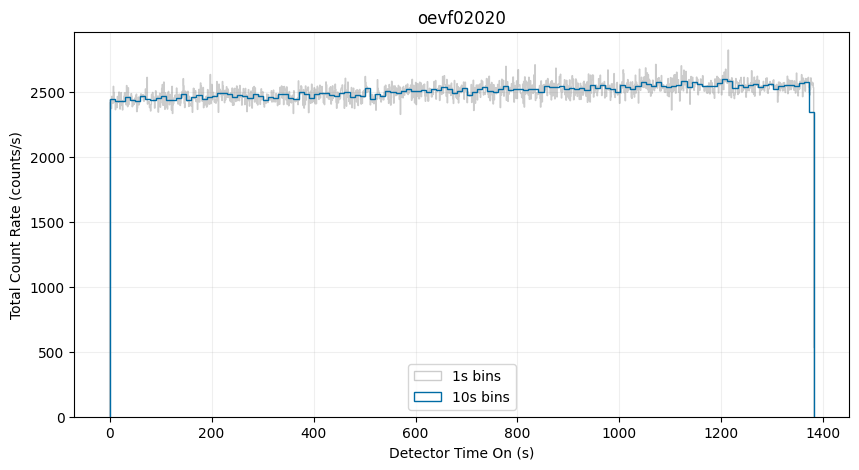

In [7]:
# Histogram of counts over an exposure with a single GTI
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 5)
with fits.open(nuv_tag) as tag:
    maxt = int(np.ceil(tag[1].data['TIME'].max()))
    rootname = fits.getheader(nuv_tag, ext=0)['ROOTNAME']
    
    labeled = True
    # 1 s bins:
    ax.hist(
        tag[1].data['TIME'],
        range=[0, maxt],
        bins=maxt,
        histtype='step',
        alpha=0.4,
        color='0.5',
        linewidth=1,
        label='1s bins')
        
    # 10 s bins:
    binsize = 10
    ax.hist(
        tag[1].data['TIME'],
        range=[0, maxt],
        bins=maxt//binsize,
        histtype='step',
        weights=np.zeros_like(tag[1].data['TIME']) + 1./binsize,
        label='10s bins',
        linewidth=1)
    
ax.set_title(rootname)
ax.legend(loc='lower center')
ax.set_ylabel('Total Count Rate (counts/s)')
ax.set_xlabel('Detector Time On (s)')
ax.grid(True, alpha=0.2)

You can also create a time-series of a subsection of the detector.  Below, we will show only the counts from the central region of the detector:

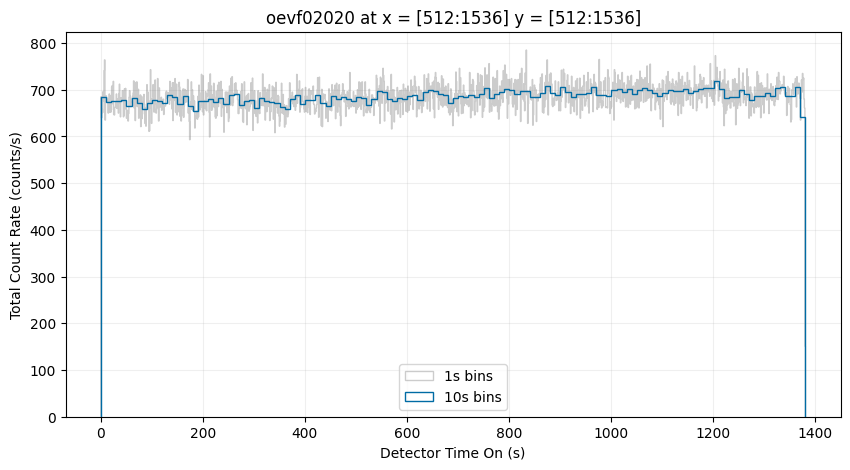

In [8]:
# Histogram of counts over an exposure with a single GTI
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 5)
with fits.open(nuv_tag) as tag:
    maxt = int(np.ceil(tag[1].data['TIME'].max()))
    rootname = fits.getheader(nuv_tag, ext=0)['ROOTNAME']

    # Define region in x and y
    xmin, xmax = 512, 1536
    ymin, ymax = 512, 1536

    region = (
        (tag[1].data['AXIS1'] >= xmin) &
        (tag[1].data['AXIS1'] <= xmax) &
        (tag[1].data['AXIS2'] >= ymin) &
        (tag[1].data['AXIS2'] <= ymax)
    )
    
    labeled = True
    # 1 s bins:
    ax.hist(
        tag[1].data['TIME'][region], # Create histogram only using selected region
        range=[0, maxt],
        bins=maxt,
        histtype='step',
        alpha=0.4,
        color='0.5',
        linewidth=1,
        label='1s bins')
        
    # 10 s bins:
    binsize = 10
    ax.hist(
        tag[1].data['TIME'][region],
        range=[0, maxt],
        bins=maxt//binsize,
        histtype='step',
        weights=np.zeros_like(tag[1].data['TIME'][region]) + 1./binsize,
        label='10s bins',
        linewidth=1)
    
ax.set_title(rootname + ' at x = [512:1536] y = [512:1536]')
ax.legend(loc='lower center')
ax.set_ylabel('Total Count Rate (counts/s)')
ax.set_xlabel('Detector Time On (s)')
ax.grid(True, alpha=0.2)

Below is an example dataset that contains multiple buffer overflows, resulting in several GTI:

In [9]:
%%capture --no-display
buffer_tag = Path('./data/mastDownload/HST/ofh317010/ofh317010_tag.fits')

# Display start and stop times of the GTI table
Table.read(buffer_tag, hdu=2)

START,STOP
seconds,seconds
float64,float64
0.030375,303.259125
311.584,409.95475
429.632,527.78575
547.552,644.727875
665.504,761.682875
783.552,880.32825
901.504,997.3568750000001
1019.488125,1116.987375


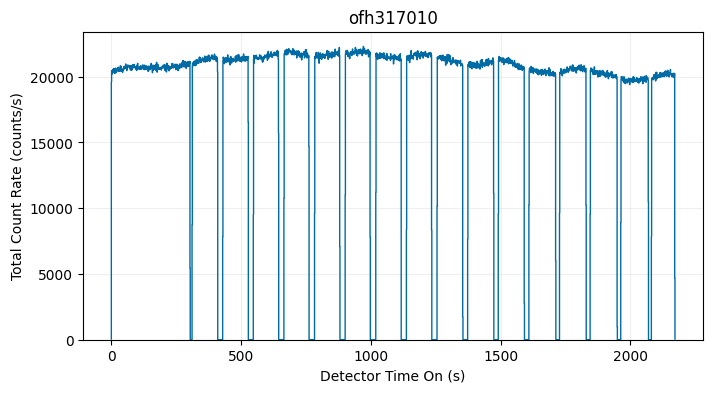

In [10]:
# Histogram of counts over an exposure with multiple GTI
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 4)
with fits.open(buffer_tag) as tag:
    maxt = int(np.ceil(tag[1].data['TIME'].max()))
    rootname = fits.getheader(buffer_tag, ext=0)['ROOTNAME']

    # 1 s bins:
    ax.hist(
        tag[1].data['TIME'],
        range=[0, maxt],
        bins=maxt,
        histtype='step',
        linewidth=1)
    
    ax.set_title(rootname)
    ax.set_ylabel('Total Count Rate (counts/s)')
    ax.set_xlabel('Detector Time On (s)')
    ax.grid(True, alpha=0.2)

<a id=Visualizing-Raw-Data-As-A-2D-Histogram></a>
## Visualizing Raw Data as a 2D Histogram (i.e., Create an Image)

Another way to visualize the raw TIME-TAG data is with a 2D histogram in the spatial dimensions. The native 2048 x 2048 high-resolution version of the data contains uncalibrated sensitivity differences between the even and odd rows, resulting in a fixed pattern noise (the boxes seen in the left plot) in our visualization. To mitigate this issue, we can down-sample to a 1024 x 1024 low-resolution format (as seen in the right plot).

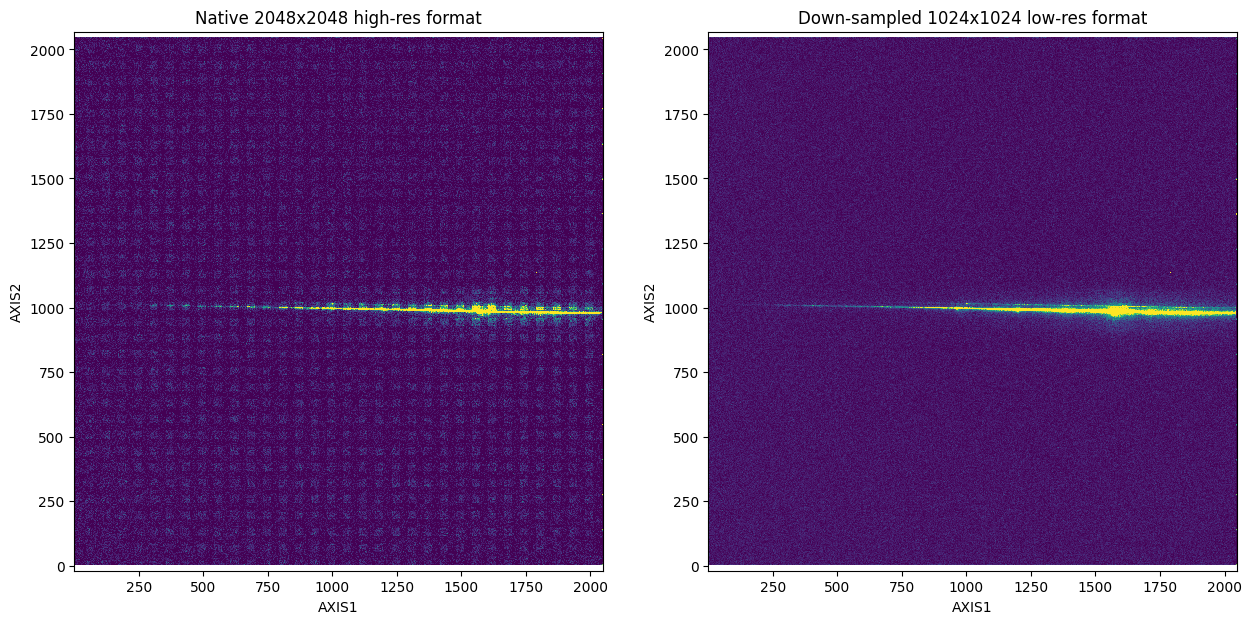

In [11]:
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(15, 7)
with fits.open(nuv_tag) as tag:
    rootname = fits.getheader(nuv_tag, ext=0)['ROOTNAME']

    # 2048x2048
    axes[0].hist2d(
        tag[1].data['AXIS1'], tag[1].data['AXIS2'],
        bins=[2048, 2048],
        range=[[1, 2048], [1, 2048]],
        vmin=0, vmax=15)
    
    axes[0].axis('equal')
    axes[0].set_xlabel('AXIS1')
    axes[0].set_ylabel('AXIS2')
    axes[0].set_title('Native 2048x2048 high-res format')

    # 1024x1024
    axes[1].hist2d(
        tag[1].data['AXIS1'], tag[1].data['AXIS2'],
        bins=[1024, 1024],
        range=[[1, 2048], [1, 2048]],
        vmin=0, vmax=45)
    
    axes[1].axis('equal')
    axes[1].set_xlabel('AXIS1')
    axes[1].set_ylabel('AXIS2')
    axes[1].set_title('Down-sampled 1024x1024 low-res format')


You can also create a time-series of the 2D histogram. Below, we will split the full exposure into three parts for the time-series:

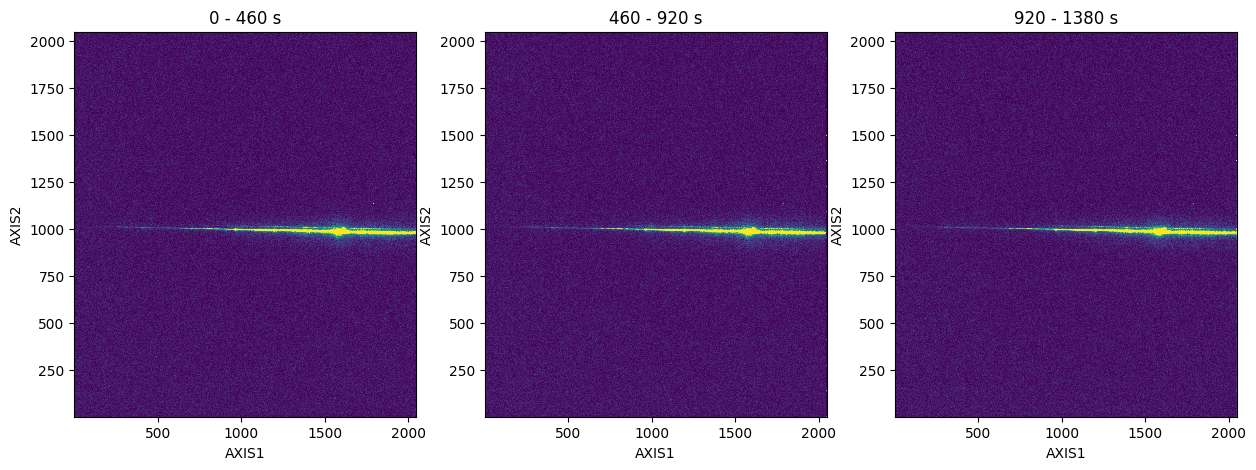

In [12]:
# split the raw TIME-TAG data into multiple 2D histograms

fig, axes = plt.subplots(1, 3)
fig.set_size_inches(15, 5)

with fits.open(nuv_tag) as tag:
    maxt = int(np.ceil(tag[1].data['TIME'].max()))

    step = 460 # seconds
    starts = range(0, maxt, step)
    stops = range(step, maxt + step, step)

    for i, (start, stop, ax) in enumerate(zip(starts, stops, axes)):
        w = (tag[1].data['TIME']) >= start & (tag[1].data['TIME'] < stop)
        ax.hist2d(tag[1].data['AXIS1'][w], tag[1].data['AXIS2'][w], 
                  bins=[1024, 1024],
                  range=[[1, 2048], [1, 2048]],
                  vmin=0, vmax=45)
        
        ax.set_title(f"{start:.0f} - {stop:.0f} s")
        ax.set_xlabel('AXIS1')
        ax.set_ylabel('AXIS2')
        

<a id=Calibrating-Data-With-Inttag></a>
## Calibrating Data with `inttag`

When calibrating TIME-TAG data, the STIS pipeline collapses a TIME-TAG event series into a single time integrated image and processes it as if it were an ACCUM mode image. This calibration is done automatically on any TIME-TAG data and the full exposure calibrated data can be retrieved from [MAST](https://mast.stsci.edu/search/ui/#/hst). If, for any reason, the full TIME-TAG exposure needs to be recalibrated you use the following steps:

The first step makes use of the [stistools](https://stistools.readthedocs.io/en/latest/index.html) package [`inttag`](https://stistools.readthedocs.io/en/latest/inttag.html) function, to convert the TIME-TAG data into an integrated ACCUM image. In the case of multiple GTI, `inttag` will only include events in the final image that are within the good time intervals.

Next, [calstis](https://stistools.readthedocs.io/en/latest/calstis.html) is called to process the raw data into three calibrated files: the fully calibrated 1-D extracted spectra (_x1d.fits), the calibrated 2-D spectral or geometrically corrected image (_x2d.fits), and the flat-fielded image (_flt.fits). We will be focusing on the x1d and flt files in this notebook.

Note that `inttag` and `calstis` will not overwrite files if run multiple times. To prevent this issue, we will delete any previously calibrated files in the directory. Alternatively, you may also create new filepaths each time the notebook is run.


<a id=Calibrating-Full-Tag-File></a>
### Calibrating Full Tag File

Here we will convert a full TIME-TAG exposure to ACCUM and plot the resulting calibrated spectra and flat-fielded image. These calibrated files will be equivalent to those that are downloadable directly from [MAST](https://mast.stsci.edu/search/ui/#/hst).

We will also need to set up a few paths for [CRDS](https://hst-crds.stsci.edu/) to get the necessary reference files.

In [13]:
# Set up CRDS
crds_path = os.path.expanduser("~/crds_cache")
os.environ["CRDS_PATH"] = crds_path
os.environ["CRDS_SERVER_URL"] = "https://hst-crds.stsci.edu"
os.environ["oref"] = os.path.join(crds_path, "references/hst/oref/")

# Sync reference files for o61s03020_tag.fits
!crds bestrefs --update-bestrefs --sync-references=1 --files ./data/mastDownload/HST/o61s03020/o61s03020_tag.fits

CRDS - INFO -  No comparison context or source comparison requested.


CRDS - INFO -  ===> Processing ./data/mastDownload/HST/o61s03020/o61s03020_tag.fits


CRDS - INFO -  0 errors
CRDS - INFO -  0 warnings
CRDS - INFO -  2 infos


In [14]:
fuv_tag = Path('./data/mastDownload/HST/o61s03020/o61s03020_tag.fits')

# Set output raw ACCUM path and name
fuv_full_raw = './data/mastDownload/HST/o61s03020/o61s03020_full_raw.fits'

# Remove any previously created files if they exist
if os.path.exists(fuv_full_raw):
    os.remove(fuv_full_raw)

# Use default inttag settings to get 1 full raw exposure (default rcount=1)
stistools.inttag.inttag(fuv_tag, fuv_full_raw)

imset: 1, start: 0.03975, stop: 2700.222, exposure time: 2700.1822500000003


In [15]:
fuv_wav = Path('./data/mastDownload/HST/o61s03020/o61s03020_wav.fits')

# Don't extract 2D image when we call calstis
fits.setval(fuv_full_raw, ext=0, keyword='X2DCORR', value='OMIT')

# Remove any previously created files if they exist
if os.path.exists('./data/mastDownload/HST/o61s03020/o61s03020_full_flt.fits'):
    os.remove('./data/mastDownload/HST/o61s03020/o61s03020_full_flt.fits')
if os.path.exists('./data/mastDownload/HST/o61s03020/o61s03020_full_x1d.fits'):
    os.remove('./data/mastDownload/HST/o61s03020/o61s03020_full_x1d.fits')

# Calibrate raw ACCUM and output x1d, and flt files
stistools.calstis.calstis(fuv_full_raw, fuv_wav)

clear_output()

Below, we plot the calibrated spectra of the full exposure (which is identical to the full exposure calibrated data retrievable on [MAST](https://mast.stsci.edu/search/ui/#/hst)):

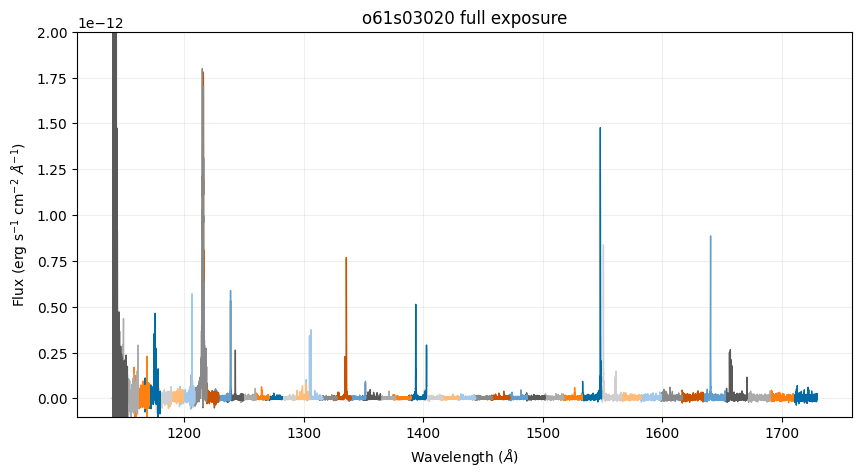

In [16]:
fuv_full_x1d = Path('./data/mastDownload/HST/o61s03020/o61s03020_full_x1d.fits')

# Plot full exposure, all spectral orders, flux vs wavelength
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 5)

with fits.open(fuv_full_x1d) as x1d:
    for i in range(len(x1d[1].data['WAVELENGTH'])):
        ax.plot(x1d[1].data['WAVELENGTH'][i], x1d[1].data['FLUX'][i], linewidth=1)

ax.set_title('o61s03020 full exposure')
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ax.set_ylim(-0.1e-12, 2e-12)
ax.grid(True, alpha=0.2)
plt.show()

Below, we plot the flat-fielded full exposure:

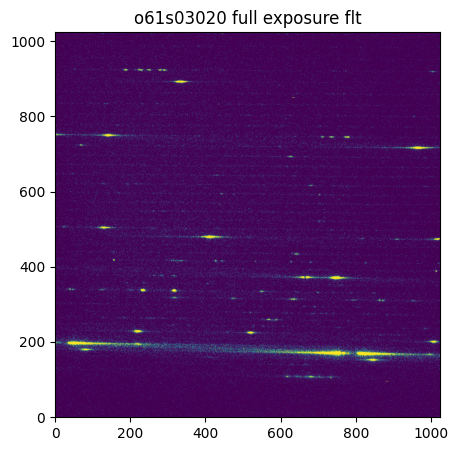

In [17]:
fuv_full_flt = Path('./data/mastDownload/HST/o61s03020/o61s03020_full_flt.fits')

# Plot the flt image
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5, 5)

with fits.open(fuv_full_flt) as flt:
    ax.imshow(
        flt[1].data,
        origin='lower',
        vmin=0, vmax=5)
    
ax.set_title('o61s03020 full exposure flt')
plt.show()

<a id=Creating-And-Calibrating-Sub-Exposures></a>
### Creating and Calibrating Sub-Exposures

Here we will divide the tag file into integrated sub-exposures and plot the resulting calibrated spectra and flat-fielded image.

The desired number of sub-exposures can be set either by specifing `rcount` or by specifying `increment` (or both). A quick method of determining `rcount` is dividing GTI by the desired `increment`. The last sub-exposure can be incomplete if there's not an even `increment` between sub-exposures, you may wish to double check your sub-exposure times to make sure they are consistent.

When tag files are split, the associated files (raw, x1d, flt) will have an additional SCI extension for each sub-exposure.

Here we will get just 4 sub-exposures:

In [18]:
# Find desired increment
with fits.open(fuv_tag) as tag:
    gti = tag[2].data['STOP'] - tag[2].data['START']
    print(gti/4)

[675.0455625]


In [19]:
# Set output raw ACCUM path and name
fuv_sub_raw = './data/mastDownload/HST/o61s03020/o61s03020_sub_raw.fits'

# Remove any previously created files if they exist
if os.path.exists(fuv_sub_raw):
    os.remove(fuv_sub_raw)

# Use inttag to get exposures with desired increment and rcount
stistools.inttag.inttag(fuv_tag, fuv_sub_raw, increment=675, rcount=4)

imset: 1, start: 0.03975, stop: 675.03975, exposure time: 675.0
imset: 2, start: 675.03975, stop: 1350.03975, exposure time: 674.9999999999999
imset: 3, start: 1350.03975, stop: 2025.03975, exposure time: 675.0
imset: 4, start: 2025.03975, stop: 2700.03975, exposure time: 675.0


In [20]:
# Don't extract 2D image when we call calstis
fits.setval(fuv_sub_raw, ext=0, keyword='X2DCORR', value='OMIT')

# Remove any previously created files if they exist
if os.path.exists('./data/mastDownload/HST/o61s03020/o61s03020_sub_flt.fits'):
    os.remove('./data/mastDownload/HST/o61s03020/o61s03020_sub_flt.fits')
if os.path.exists('./data/mastDownload/HST/o61s03020/o61s03020_sub_x1d.fits'):
    os.remove('./data/mastDownload/HST/o61s03020/o61s03020_sub_x1d.fits')

# Use calstis to get x1d and flt with sub-exposures
stistools.calstis.calstis(fuv_sub_raw, fuv_wav)

clear_output()

Below, we plot the calibrated spectra sub-exposures and specifically focus on the $\texttt{C}_{\texttt{IV}}$ emission line doublet. With the y-axes set with the same limits, there is a clearly visible increase in flux in the third split:

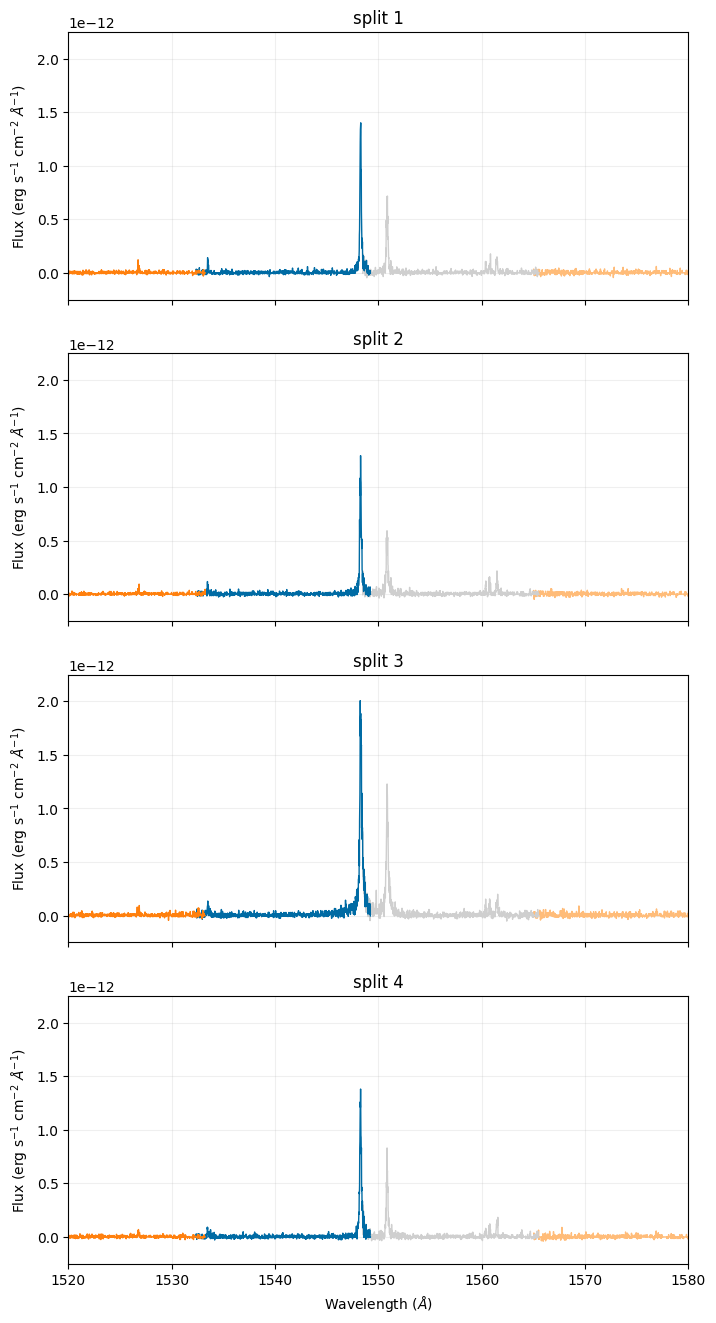

In [21]:
fuv_sub_x1d = Path('./data/mastDownload/HST/o61s03020/o61s03020_sub_x1d.fits')

# Plot each sub-exposure flux vs wavelength
fig, axes = plt.subplots(4, 1, sharex=True)
fig.set_size_inches(8, 16)

with fits.open(fuv_sub_x1d) as x1d:
    for i in range(len(x1d[1].data['WAVELENGTH'])):
        for n in range(4):
            axes[n].plot(x1d[n+1].data['WAVELENGTH'][i], x1d[n+1].data['FLUX'][i], linewidth=1)

for i in range(len(axes)):
    axes[i].set_ylim(-0.25e-12, 2.25e-12)
    axes[i].set_xlim(1520, 1580)
    axes[i].set_title("split " + str(i + 1))
    axes[3].set_xlabel(r"Wavelength ($\AA$)")
    axes[i].set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
    axes[i].grid(True, alpha=0.2)

Below, we plot the flat-fielded sub-exposures. With the colorbars set the same for each plot, the increase in flux across the continuum is clearly visible in the third split:

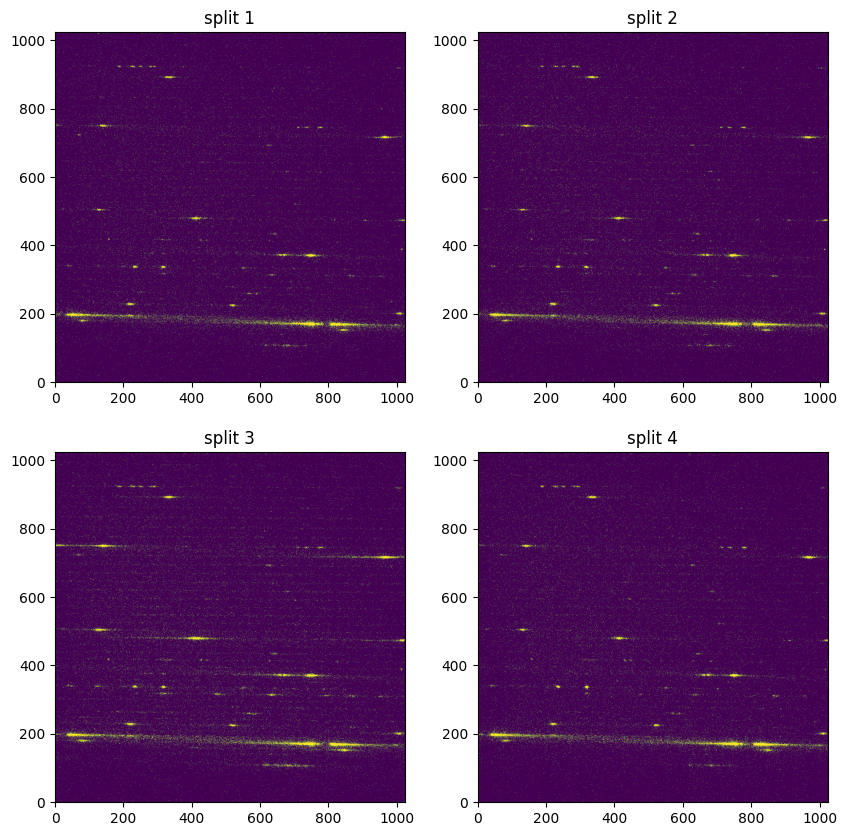

In [22]:
fuv_sub_flt = Path('./data/mastDownload/HST/o61s03020/o61s03020_sub_flt.fits')

# Plot the flt images
fig, axes = plt.subplots(2, 2)
fig.set_size_inches(10, 10)
with fits.open(fuv_sub_flt) as flt:
    axes[0,0].imshow(flt[1].data, 
                   origin='lower', 
                   vmin=0, vmax=1.25)
    axes[0,1].imshow(flt[4].data, 
                   origin='lower',
                   vmin=0, vmax=1.25)
    axes[1,0].imshow(flt[7].data, 
                   origin='lower',
                   vmin=0, vmax=1.25)
    axes[1,1].imshow(flt[10].data, 
                   origin='lower',
                   vmin=0, vmax=1.25)
    
axes[0,0].set_title('split 1')
axes[0,1].set_title('split 2')
axes[1,0].set_title('split 3')
axes[1,1].set_title('split 4')
plt.show()

<a id=Exploring-Special-Cases></a>
## Exploring Special Cases

<a id=Set-Extraction-Position></a>
### Extraction Position Drift in Sub-exposures

When calibrating sub-exposures with small time increments or high background, the resulting low signal-to-noise (SNR) can introduce several sources of error (see also [Low Count Uncertainties in STIS](https://spacetelescope.github.io/hst_notebooks/notebooks/STIS/low_count_uncertainties/Low_Count_Uncertainties.html) for a full discussion on appropriate error approximations to use for low-count STIS data). 

`stistools.x1d.x1d` uses cross-correlation to find the extraction position for each sub-exposure. If the SNR is low enough, this can lead to the default calstis extraction position to move between each sub-exposure. Note that in some cases, the drift in extraction center may be tracking real motion on the detector, which may be determined by careful analysis of the jitter files (see [Hubble's Jitter Files and Orientation Overview](https://www.stsci.edu/hst/instrumentation/focus-and-pointing/pointing) for more information). The STIS team maintains a [monitor](https://www.stsci.edu/~STIS/monitors/jitter/) for quick visual inspection of jitter during an observation. For the dataset plotted below, no systematic drift was noted.

The figure below shows the dynamic extraction positions from a dataset calibrated with a small time increment of 10 seconds, compared to the static extraction position determined by the calstis pipeline for a full exposure of the same dataset. Without defining the extraction position, the `A2CENTER` drifted by 0.18 pixels (~4.5 mas) over the sub-exposures.

<img src="oemw01030_a2centers.png" alt="Plot of extraction positions in sub-exposures compared to static extraction position from full exposure." style="width: 500px;"/>

To ensure data are calibrated consistently, we can set the extraction position for all sub-exposures to match the `A2CENTER` value provided by the calibrated full exposure. We will also need to force calstis to extract at the specified `A2CENTER` by setting `maxsrch` to zero. 

In the following example, we will re-calibrate the same data used in earlier in this notebook (oevf02020) with a shorter time increment and a fixed extraction position.

In [23]:
# path of full exposure x1d downloaded from MAST
nuv_full_x1d = './data/mastDownload/HST/oevf02020/oevf02020_x1d.fits'

# path of wavelength file downloaded from MAST
nuv_wav = './data/mastDownload/HST/oevf02020/oevf02020_wav.fits'

# new split sub-exposure file paths
nuv_split_raw = './data/mastDownload/HST/oevf02020/oevf02020_split_raw.fits'
nuv_split_flt = './data/mastDownload/HST/oevf02020/oevf02020_split_flt.fits'
nuv_split_x1d = './data/mastDownload/HST/oevf02020/oevf02020_split_x1d.fits'

# Get extraction position from the full exposure x1d:
a2center_pos = fits.getdata(nuv_full_x1d, ext=1)['A2CENTER'][0]

In [24]:
# Sync reference files for oevf02020_tag.fits
!crds bestrefs --update-bestrefs --sync-references=1 --files ./data/mastDownload/HST/oevf02020/oevf02020_tag.fits

CRDS - INFO -  No comparison context or source comparison requested.


CRDS - INFO -  ===> Processing ./data/mastDownload/HST/oevf02020/oevf02020_tag.fits


CRDS - INFO -  0 errors
CRDS - INFO -  0 warnings
CRDS - INFO -  2 infos


In [25]:
# Remove any previously created files if they exist:
if os.path.exists(nuv_split_raw):
    os.remove(nuv_split_raw)

# Use inttag to get exposures with desired increment and rcount:
stistools.inttag.inttag(nuv_tag, nuv_split_raw, increment=60, rcount=23)

clear_output()

In [26]:
# Remove any previously created files if they exist:
if os.path.exists(nuv_split_flt):
    os.remove(nuv_split_flt)

# Don't extract 1D spectrum when we call calstis:
fits.setval(nuv_split_raw, ext=0, keyword='X1DCORR', value='OMIT')

# Call calstis and create FLT file:
stistools.calstis.calstis(nuv_split_raw, nuv_wav)

clear_output()

In [27]:
# Remove any previously created files if they exist:
if os.path.exists(nuv_split_x1d):
    os.remove(nuv_split_x1d)

# Run 1D extraction on each sub-exposure, but specify the high-SNR-derived extraction
# position from the full pipeline file explicitly:
stistools.x1d.x1d(
    nuv_split_flt,
    ctecorr='omit', # CTE correction for CCD only
    a2center = a2center_pos, # provide extraction position
    maxsrch=0,      # force extraction at the a2center position
    bk1size=None,   # adjust as necessary
    bk2size=None,   # adjust as necessary
    bk1offst=None,  # adjust as necessary
    bk2offst=None   # adjust as necessary
    )

clear_output()

<a id=Creating-Light-Curves></a>
### Creating Light Curves

Let's create a light curve of the AD Leo flare seen in dataset o61s03020. Here we examine the $\texttt{C}_{\texttt{IV}}$ emission line doublet, which can be found at 1548.202 and 1550.774 $\text{\AA}$. As the doublet straddles two spectral orders, we can choose either the 95th or 96th order (1548.476-1565.54 $\text{\AA}$ and 1532.332-1549.216 $\text{\AA}$, respectively). 

For more information on how to select the spectral order for your combination of detector, optical element, and central wavelength see the spectral format plots on the [STIS Spectroscopic Capabilities webpage](https://www.stsci.edu/hst/instrumentation/stis/instrument-design/gratings--prism).

First, we will split our FUV data into more sub-exposures and calibrate:

In [28]:
# new split sub-exposure file paths
fuv_split_raw = './data/mastDownload/HST/o61s03020/o61s03020_split_raw.fits'
fuv_split_flt = './data/mastDownload/HST/o61s03020/o61s03020_split_flt.fits'
fuv_split_x1d = './data/mastDownload/HST/o61s03020/o61s03020_split_x1d.fits'

# Remove any previously created files if they exist:
if os.path.exists(fuv_split_raw):
    os.remove(fuv_split_raw)

# Use inttag to get exposures with desired increment and rcount:
stistools.inttag.inttag(fuv_tag, fuv_split_raw, increment=50, rcount=54)

clear_output()

In [29]:
# Remove any previously created files if they exist:
if os.path.exists(fuv_split_flt):
    os.remove(fuv_split_flt)
if os.path.exists(fuv_split_x1d):
    os.remove(fuv_split_x1d)

# Don't extract 2D spectrum when we call calstis:
fits.setval(fuv_split_raw, ext=0, keyword='X2DCORR', value='OMIT')

# Call calstis and create FLT and X1D files:
stistools.calstis.calstis(fuv_split_raw, fuv_wav)

clear_output()

Here we use the 95th spectral order and integrate the flux in each sub-exposure over wavelength using `scipy.integrate.trapezoid`. The resulting light curve shows the flare in the $\texttt{C}_{\texttt{IV}}$ line, allowing flare property measurements such as the flare duration.

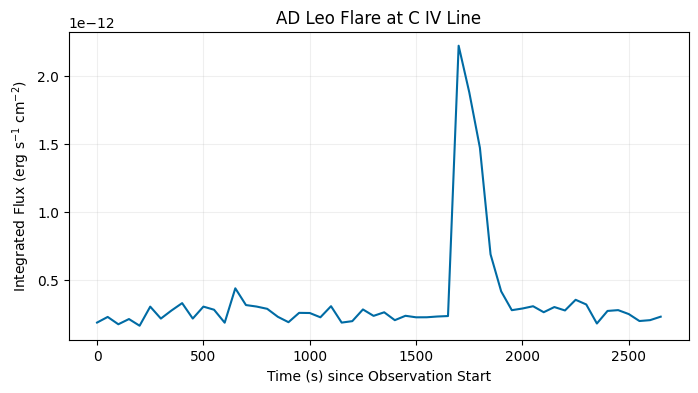

In [30]:
with fits.open(fuv_split_x1d) as x1d:
    # select spectral order 95 to get part of the C IV emission line doublet
    order = np.where((x1d[1].data['SPORDER']==95))

    int_flux = []
    time = []
    for n in range(len(x1d)-1): # number of extensions minus the primary header
        wav = (x1d[n+1].data['WAVELENGTH'][order]) #filter wavelength by spectral order
        flux = (x1d[n+1].data['FLUX'][order]) # filter flux by spectral order
        int_flux.append(scipy.integrate.trapezoid(flux, x=wav)) # integrate flux over wavelength
        time.append(n * x1d[n+1].header['EXPTIME']) # multiply extension number by exposure time

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 4)
ax.plot(time, int_flux)
ax.set_xlabel('Time (s) since Observation Start')
ax.set_ylabel(r"Integrated Flux (erg s$^{-1}$ cm$^{-2}$)")
ax.set_title('AD Leo Flare at C IV Line')
ax.grid(True, alpha=0.2)


---
## About this Notebook
**Author:** [Jacqueline Brown](jbrown@stsci.edu)

**Updated On:** 2026-05-04


> *This tutorial was written to be in compliance with the [STScI style guides](https://github.com/spacetelescope/style-guides).*

## Acknowledgements

This notebook has been developed with support from Sean Lockwood.


## Citations

I. Dashevsky, et al., "STIS Time-Tag Analysis Guide," [Instrument Science Report STIS 2000-02](https://www.stsci.edu/files/live/sites/www/files/home/hst/instrumentation/stis/documentation/instrument-science-reports/_documents/200002.pdf)

E. Rickman and J. Brown, et al., 2025, [STIS Instrument Handbook](https://hst-docs.stsci.edu/stisihb), Version 25.0,
(Baltimore: STScI)

E. Rickman and J. Brown, et al., 2024, [STIS Data Handbook](https://hst-docs.stsci.edu/stisdhb), Version 8.0, (Baltimore:
STScI)

J. Lothringer, et al., "Uncertainties in Low-Count STIS Spectra," [Instrument Science Report STIS 2025-04](https://www.stsci.edu/files/live/sites/www/files/home/hst/instrumentation/stis/documentation/instrument-science-reports/_documents/STIS_ISR_2025-04.pdf)

If you use `astropy`, `matplotlib`, `astroquery`, `numpy`, or `scipy` for published research, please cite the
authors. Follow these links for more information about citations:

* [Citing `matplotlib`](https://matplotlib.org/stable/users/project/citing.html)
* [Citing `numpy`](https://numpy.org/citing-numpy/)
* [Citing `astroquery`](https://astroquery.readthedocs.io/en/latest/)
* [Citing `astropy`](https://www.astropy.org/acknowledging.html)
* [Citing `scipy`](https://scipy.org/citing-scipy/)

---

[Top of Page](#top)
<img style="float: right;" src="https://raw.githubusercontent.com/spacetelescope/notebooks/master/assets/stsci_pri_combo_mark_horizonal_white_bkgd.png" alt="Space Telescope Logo" width="200px"/> 